In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

print("All packages imported successfully! 🚀")
print(f"Lightkurve version: {lk.__version__}")

Matplotlib is building the font cache; this may take a moment.


All packages imported successfully! 🚀
Lightkurve version: 2.6.0


/Users/simalnaz/Documents/exoplanet-detector/venv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
import lightkurve as lk
import numpy as np

# Download raw light curve data for Kepler-452
search_result = lk.search_lightcurve("Kepler-452", mission="Kepler", quarter=6)
lc = search_result[0].download()

# Extract the raw arrays
time = lc.time.value        
flux = lc.flux.value        
flux_err = lc.flux_err.value  

print(f"Number of data points: {len(time)}")
print(f"Time range: {time[0]:.2f} to {time[-1]:.2f} days")
print(f"First 5 flux values: {flux[:5]}")

Number of data points: 4276
Time range: 539.47 to 629.30 days
First 5 flux values: [64021.52  64031.01  64026.86  64019.35  64020.273]


In [3]:
import matplotlib.pyplot as plt
import sys
sys.path.append('.')  
from utils import normalise

# Apply normalisation
norm_flux = normalise(flux)

print(f"Before normalisation - mean: {flux.mean():.1f}")
print(f"After normalisation  - mean: {norm_flux.mean():.4f}")
print(f"First 5 normalised values: {norm_flux[:5]}")

Before normalisation - mean: 64019.2
After normalisation  - mean: 1.0000
First 5 normalised values: [1.000044  1.0001922 1.0001273 1.00001   1.0000244]


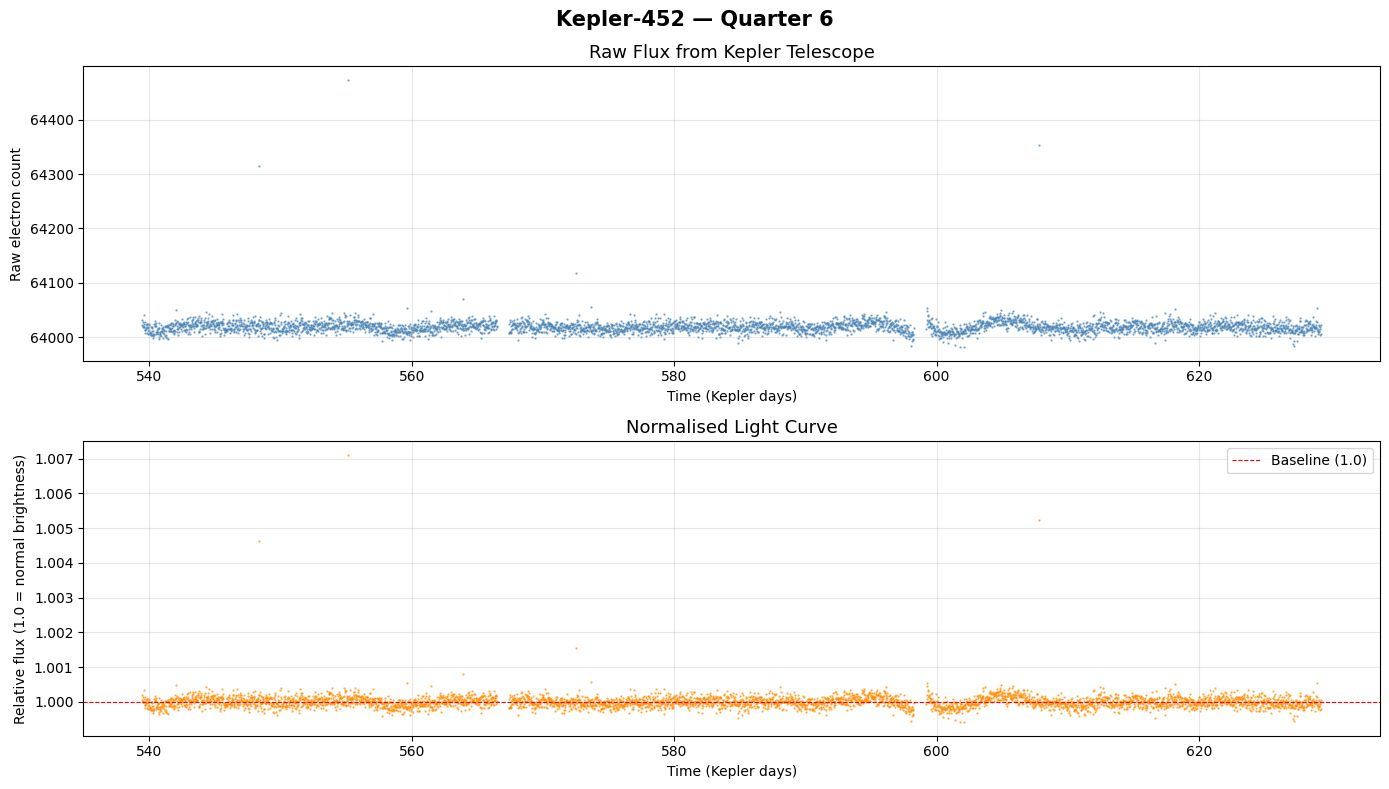

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

#Top plot: raw flux
axes[0].scatter(time, flux, s=0.5, color='steelblue', alpha=0.6)
axes[0].set_title('Raw Flux from Kepler Telescope', fontsize=13)
axes[0].set_xlabel('Time (Kepler days)')
axes[0].set_ylabel('Raw electron count')
axes[0].grid(True, alpha=0.3)

#Bottom plot: normalised flux
axes[1].scatter(time, norm_flux, s=0.5, color='darkorange', alpha=0.6)
axes[1].set_title('Normalised Light Curve', fontsize=13)
axes[1].set_xlabel('Time (Kepler days)')
axes[1].set_ylabel('Relative flux (1.0 = normal brightness)')
axes[1].axhline(y=1.0, color='red', linewidth=0.8, linestyle='--', label='Baseline (1.0)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Kepler-452 — Quarter 6', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
baseline = 1.0
dip = norm_flux.min()

print(f"Deepest dip in the data : {dip:.6f}")
print(f"Drop below baseline     : {(baseline - dip) * 100:.4f}%")
print(f"In raw electron counts  : {(baseline - dip) * flux.mean():.1f} electrons")

Deepest dip in the data : 0.999413
Drop below baseline     : 0.0587%
In raw electron counts  : 37.6 electrons


In [ ]:
import numpy as np

depth = 1.0 - norm_flux.min()   
r_star_in_earth_radii = 1.11 * 109.076  

r_planet = r_star_in_earth_radii * np.sqrt(depth)

print(f"Transit depth          : {depth:.6f}")
print(f"Estimated planet radius: {r_planet:.2f} Earth radii")

Transit depth          : 0.000587
Estimated planet radius: 2.93 Earth radii
